In [2]:
import os
import re
import sys
import pickle

sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from src.evaluation.metrics import tune_tfidf_params, tune_hybrid_weights
from src.recommender.hybrid import SVDHybridRecommender
from src.utils.preprocessing import (
    load_clean_data,
    preprocess_content_text,
    get_users_for_eval,
    prepare_matrices
)
from src.utils.mappings import get_toeic_part_mapping, get_subject_categories

np.random.seed(42)
sns.set_theme(style="whitegrid", palette="viridis")

In [3]:
# Load data
lectures_df, merged_df = load_clean_data()
print(f"Lectures: {len(lectures_df)}, Interactions: {len(merged_df)}")

Loading from paths:
Lectures: c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\data\cleaned\cleaned_lectures.csv
Merged: c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\data\cleaned\merged_cleaned_data.csv
Successfully loaded 1021 lectures and 117167 interactions
Lectures: 1021, Interactions: 117167


In [4]:
# Prepare bundle features (from notebooks/02_tf_idf.ipynb)
bundle_info = merged_df.groupby('bundle_id').agg({
    'part': 'first',
    'tags': lambda x: ';'.join(set(str(i) for i in x if pd.notna(i))),
    'question_id': lambda x: len(set(x))
}).reset_index()
bundle_info.columns = ['bundle_id', 'part', 'tags', 'question_count']
part_names = get_toeic_part_mapping()
bundle_info['part_name'] = bundle_info['part'].map(part_names)
bundle_info['subject_category'] = bundle_info['tags'].apply(lambda x: get_subject_categories(x)[0] if get_subject_categories(x) else "General")
bundle_info['content_text'] = (
    bundle_info['part_name'].fillna('') + ' ' +
    bundle_info['subject_category'].fillna('') + ' ' +
    bundle_info['tags'].fillna('')
)
bundle_info['content_text'] = bundle_info['content_text'].apply(preprocess_content_text)
bundle_info['content_text'].head()

0    part 1: listening - photographs grammar_basic ...
1    part 1: listening - photographs grammar_basic ...
2    part 1: listening - photographs grammar_basic ...
3    part 2: listening - question-response grammar_...
4    part 2: listening - question-response grammar_...
Name: content_text, dtype: object

In [5]:
# Enhanced TF-IDF tuning
tfidf_params_grid = [
    {'max_features': 3000, 'stop_words': 'english', 'ngram_range': (1, 1), 'min_df': 0.01, 'max_df': 0.95},
    {'max_features': 5000, 'stop_words': 'english', 'ngram_range': (1, 2), 'min_df': 0.01, 'max_df': 0.95},
    {'max_features': 7000, 'stop_words': 'english', 'ngram_range': (1, 2), 'min_df': 0.005, 'max_df': 0.90},
    {'max_features': 10000, 'stop_words': 'english', 'ngram_range': (1, 3), 'min_df': 0.005, 'max_df': 0.85}
]

def build_recommend_fn(tfidf_matrix, vectorizer, min_similarity=0.1):
    sim = cosine_similarity(tfidf_matrix)
    indices = pd.Series(bundle_info.index, index=bundle_info['bundle_id'])
    def recommend_fn(user_id, k=10):
        try:
            user_history = merged_df[merged_df['user_id'] == user_id]
            seen_bundles = set(user_history['bundle_id'].unique())
            rec_scores = {}
            for b in seen_bundles:
                if b not in indices:
                    continue
                idx = indices[b]
                for i, score in enumerate(sim[idx]):
                    b_id = bundle_info.iloc[i]['bundle_id']
                    if b_id not in seen_bundles and score >= min_similarity:
                        rec_scores[b_id] = rec_scores.get(b_id, 0) + score
            if not rec_scores:
                return []
            max_score = max(rec_scores.values())
            rec_scores = {k: v/max_score for k, v in rec_scores.items()}
            top_bundles = sorted(rec_scores.items(), key=lambda x: x[1], reverse=True)[:k]
            return top_bundles  # Return list of (bundle_id, score) tuples
        except Exception as e:
            print(f"Error in recommend_fn for user {user_id}: {str(e)}")
            return []
    return recommend_fn

Testing TF-IDF params: {'max_features': 3000, 'stop_words': 'english', 'ngram_range': (1, 1), 'min_df': 0.01, 'max_df': 0.95}
{'params': "{'max_features': 3000, 'stop_words': 'english', 'ngram_range': (1, 1), 'min_df': 0.01, 'max_df': 0.95}", 'precision': np.float64(0.0), 'recall': np.float64(0.0)}
Testing TF-IDF params: {'max_features': 5000, 'stop_words': 'english', 'ngram_range': (1, 2), 'min_df': 0.01, 'max_df': 0.95}
{'params': "{'max_features': 5000, 'stop_words': 'english', 'ngram_range': (1, 2), 'min_df': 0.01, 'max_df': 0.95}", 'precision': np.float64(0.0), 'recall': np.float64(0.0)}
Testing TF-IDF params: {'max_features': 7000, 'stop_words': 'english', 'ngram_range': (1, 2), 'min_df': 0.005, 'max_df': 0.9}
{'params': "{'max_features': 7000, 'stop_words': 'english', 'ngram_range': (1, 2), 'min_df': 0.005, 'max_df': 0.9}", 'precision': np.float64(0.0), 'recall': np.float64(0.0)}
Testing TF-IDF params: {'max_features': 10000, 'stop_words': 'english', 'ngram_range': (1, 3), 'min_

c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\src\evaluation\metrics.py:103: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


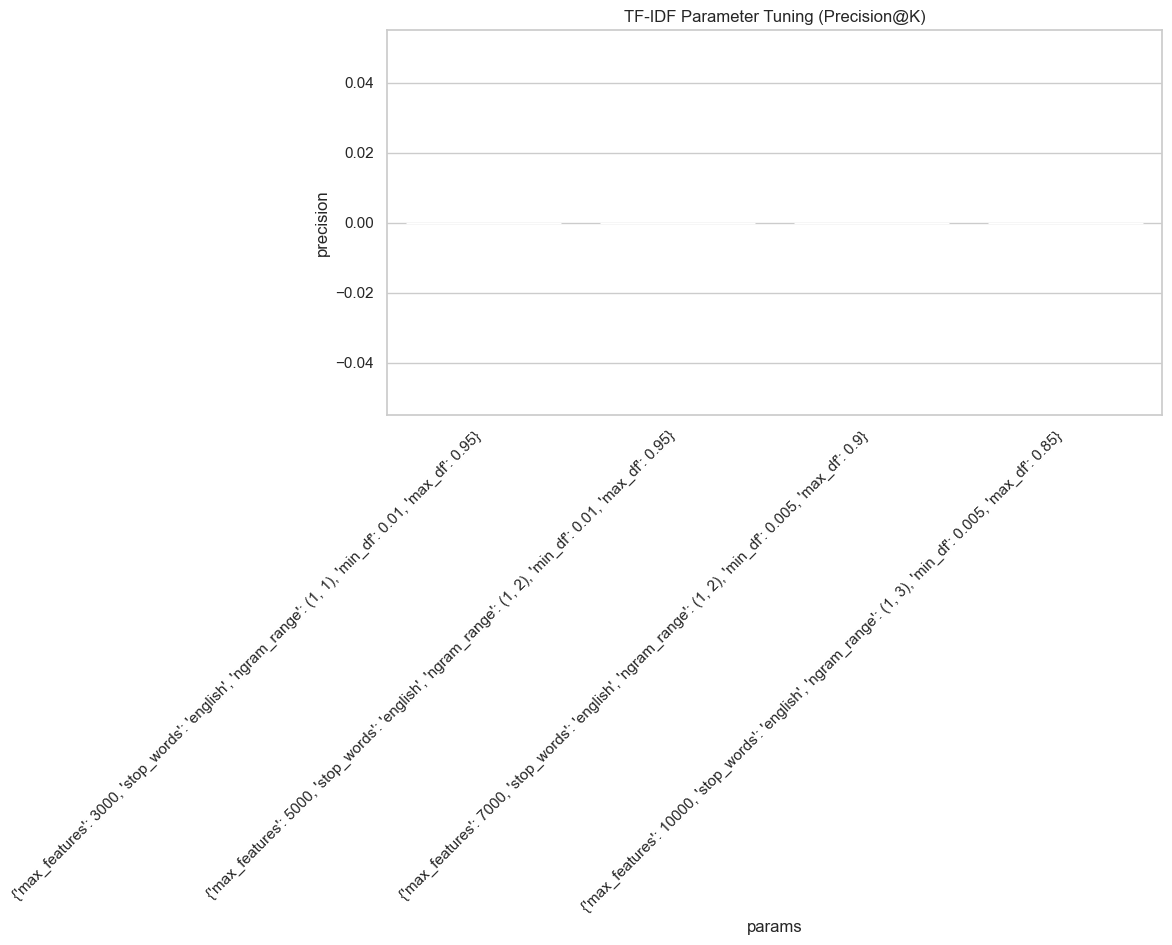

In [6]:
def get_relevant_fn(user_id):
    return merged_df[merged_df['user_id'] == user_id]['bundle_id'].unique().tolist()

tfidf_results = tune_tfidf_params(
    param_grid=tfidf_params_grid,
    vectorizer_class=TfidfVectorizer,
    X_raw=bundle_info['content_text'],
    y_true_fn=lambda: get_users_for_eval(merged_df),
    recommend_fn_builder=build_recommend_fn,
    ground_truth_fn=get_relevant_fn,
    k=10,
    output_path="../data/cleaned/tfidf_tuning_results_updated.csv"
)

In [7]:
train_matrix, test_matrix, user_map, item_map = prepare_matrices(merged_df)
reverse_item_map = {v: k for k, v in item_map.items()}

In [8]:
# Hybrid model tuning (expanded weight range)
alpha_range = [round(w, 2) for w in np.arange(0.1, 1.1, 0.05)]
train_matrix, test_matrix, user_map, item_map = prepare_matrices(merged_df)
content_similarity = cosine_similarity(TfidfVectorizer(max_features=3000, stop_words='english', ngram_range=(1, 1)).fit_transform(bundle_info['content_text']))

Testing hybrid weight: 0.1


c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\src\evaluation\metrics.py:118: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  model.fit(train_matrix, content_sim)
c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\.venv\lib\site-packages\scipy\sparse\_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
INFO:src.recommender.hybrid:SVD model trained successfully with 20 factors
INFO:src.recommender.hybrid:User factors shape: (881, 20)
INFO:src.recommender.hybrid:Item factors shape: (8256, 20)
INFO:src.recommender.hybrid:Generated 10 recommendations for user 2
INFO:src.recommender.hybrid:Generated 10 recommendations for user 3
INFO:src.recommender.hybrid:Generated 10 recommendations for user 4
INFO:src.recommender.hybrid:Generated 10 

{'weight': np.float64(0.1), 'precision@10': 0.007515923566878976, 'recall@10': 0.0018884836289589004, 'rmse': np.float64(2.344688130822845)}
Testing hybrid weight: 0.15


c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\.venv\lib\site-packages\scipy\sparse\_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
INFO:src.recommender.hybrid:SVD model trained successfully with 20 factors
INFO:src.recommender.hybrid:User factors shape: (881, 20)
INFO:src.recommender.hybrid:Item factors shape: (8256, 20)
INFO:src.recommender.hybrid:Generated 10 recommendations for user 2
INFO:src.recommender.hybrid:Generated 10 recommendations for user 3
INFO:src.recommender.hybrid:Generated 10 recommendations for user 4
INFO:src.recommender.hybrid:Generated 10 recommendations for user 5
INFO:src.recommender.hybrid:Generated 10 recommendations for user 6
INFO:src.recommender.hybrid:Generated 10 recommendations for user 7
INFO:src.recommender.hybrid:Generated 10 recommendations for user 8
INFO:src.recommender.hybrid:Generate

{'weight': np.float64(0.15), 'precision@10': 0.007643312101910824, 'recall@10': 0.0018926196203560381, 'rmse': np.float64(2.344688130822845)}
Testing hybrid weight: 0.2


...

{'weight': np.float64(0.95), 'precision@10': 0.03133757961783443, 'recall@10': 0.04500805116420214, 'rmse': np.float64(2.344688130822845)}
Testing hybrid weight: 1.0


c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\.venv\lib\site-packages\scipy\sparse\_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
INFO:src.recommender.hybrid:SVD model trained successfully with 20 factors
INFO:src.recommender.hybrid:User factors shape: (881, 20)
INFO:src.recommender.hybrid:Item factors shape: (8256, 20)
INFO:src.recommender.hybrid:Generated 10 recommendations for user 2
INFO:src.recommender.hybrid:Generated 10 recommendations for user 3
INFO:src.recommender.hybrid:Generated 10 recommendations for user 4
INFO:src.recommender.hybrid:Generated 10 recommendations for user 5
INFO:src.recommender.hybrid:Generated 10 recommendations for user 6
INFO:src.recommender.hybrid:Generated 10 recommendations for user 7
INFO:src.recommender.hybrid:Generated 10 recommendations for user 8
INFO:src.recommender.hybrid:Generate

{'weight': np.float64(1.0), 'precision@10': 0.04433121019108286, 'recall@10': 0.07348578335766467, 'rmse': np.float64(2.344688130822845)}
Testing hybrid weight: 1.05


c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\.venv\lib\site-packages\scipy\sparse\_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
INFO:src.recommender.hybrid:SVD model trained successfully with 20 factors
INFO:src.recommender.hybrid:User factors shape: (881, 20)
INFO:src.recommender.hybrid:Item factors shape: (8256, 20)
INFO:src.recommender.hybrid:Generated 10 recommendations for user 2
INFO:src.recommender.hybrid:Generated 10 recommendations for user 3
INFO:src.recommender.hybrid:Generated 10 recommendations for user 4
INFO:src.recommender.hybrid:Generated 10 recommendations for user 5
INFO:src.recommender.hybrid:Generated 10 recommendations for user 6
INFO:src.recommender.hybrid:Generated 10 recommendations for user 7
INFO:src.recommender.hybrid:Generated 10 recommendations for user 8
INFO:src.recommender.hybrid:Generate

{'weight': np.float64(1.05), 'precision@10': 0.035796178343949075, 'recall@10': 0.05680658419550986, 'rmse': np.float64(2.344688130822845)}


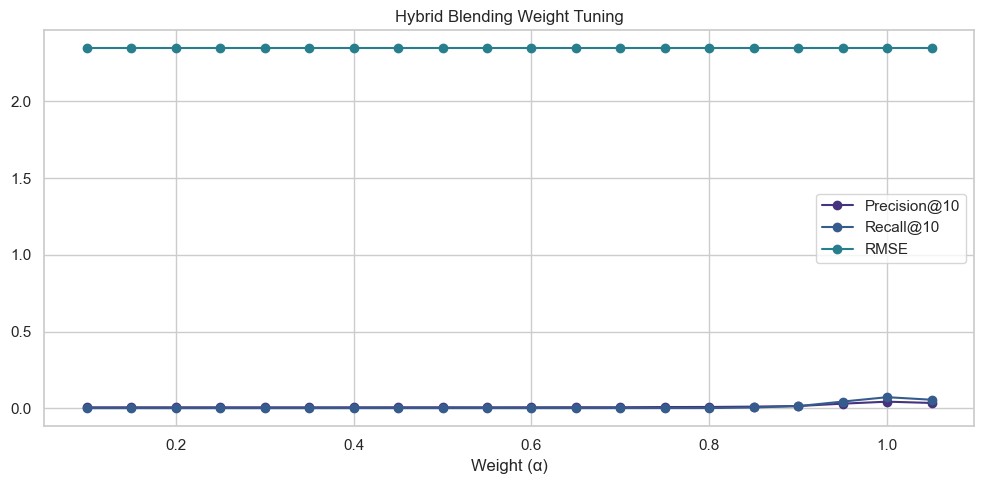

In [9]:
hybrid_results = tune_hybrid_weights(
    weights=alpha_range,
    model_class=SVDHybridRecommender,
    train_matrix=train_matrix,
    content_sim=content_similarity,
    test_matrix=test_matrix,
    precision_k=10,
    output_path="../data/cleaned/hybrid_tuning_results_updated.csv",
    user_map=user_map,
    item_map=item_map,
    reverse_item_map=reverse_item_map
)

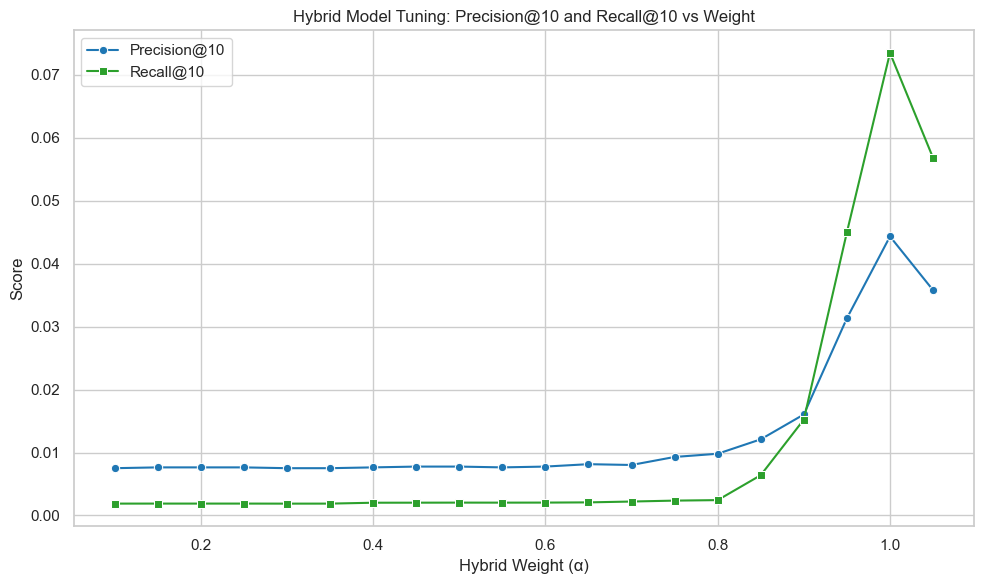

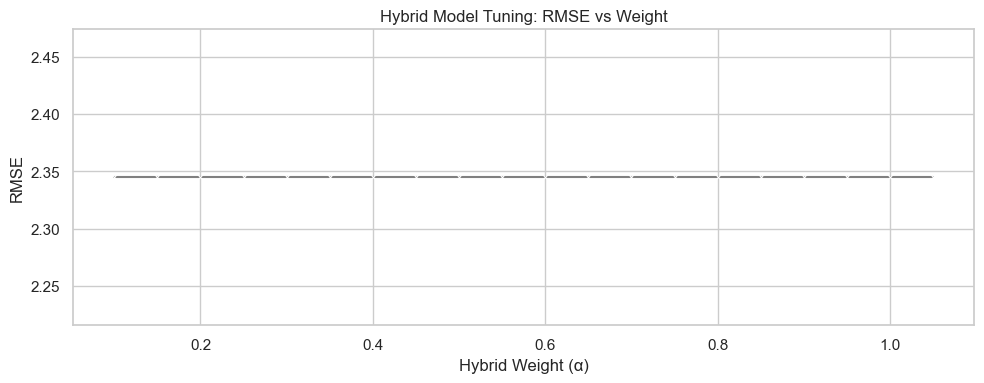

In [ ]:
# Load the tuned results
df = pd.read_csv('../data/cleaned/hybrid_tuning_results_updated.csv')

# Plot Precision@10 and Recall@10 vs Weight (α)
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='weight', y='precision@10', marker='o', label='Precision@10', color='#1f77b4')
sns.lineplot(data=df, x='weight', y='recall@10', marker='s', label='Recall@10', color='#2ca02c')

plt.title('Hybrid Model Tuning: Precision@10 and Recall@10 vs Weight')
plt.xlabel('Hybrid Weight (α)')
plt.ylabel('Score')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot RMSE vs Weight
plt.figure(figsize=(10, 4))
sns.lineplot(data=df, x='weight', y='rmse', marker='x', color='gray')

plt.title('Hybrid Model Tuning: RMSE vs Weight')
plt.xlabel('Hybrid Weight (α)')
plt.ylabel('RMSE')
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
# Save best models
best_tfidf_params = tfidf_results.loc[tfidf_results['precision'].idxmax()]['params']
best_hybrid_weight = hybrid_results.loc[hybrid_results['precision@10'].idxmax()]['weight']
print(f"Best TF-IDF params: {best_tfidf_params}")
print(f"Best hybrid weight: {best_hybrid_weight}")

Best TF-IDF params: {'max_features': 3000, 'stop_words': 'english', 'ngram_range': (1, 1), 'min_df': 0.01, 'max_df': 0.95}
Best hybrid weight: 1.0


In [14]:
# Train and save best TF-IDF model
vectorizer = TfidfVectorizer(**eval(best_tfidf_params))
tfidf_matrix = vectorizer.fit_transform(bundle_info['content_text'])
cosine_sim = cosine_similarity(tfidf_matrix)
model_data = {
    'tfidf_vectorizer': vectorizer,
    'tfidf_matrix': tfidf_matrix,
    'cosine_sim': cosine_sim,
    'bundle_features': bundle_info,
    'bundle_indices': pd.Series(bundle_info.index, index=bundle_info['bundle_id'])
}
with open('../models/content_based_model_best.pkl', 'wb') as f:
    pickle.dump(model_data, f)